# 04 — Wavetable Oscillator

Covers `cp.wavetable`: `WaveTable`, `WaveTableBank1/4`, `WavetableOscillator1/4`.

**Sections:**
1. Build and inspect a WaveTable
2. Single-table oscillator — frequency sweep
3. Linear vs Hermite interpolation — SNR comparison
4. 4-table morph bank — crossfade between waveforms
5. Phase modulation (FM via PM)
6. Hard sync — primary drives secondary
7. Interactive morph / frequency explorer
8. Live audio

In [1]:
import caspy as cp
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Audio
from scipy.signal import welch

SR = 44100
print('cp loaded')

cp loaded


## 1. Build and inspect a WaveTable

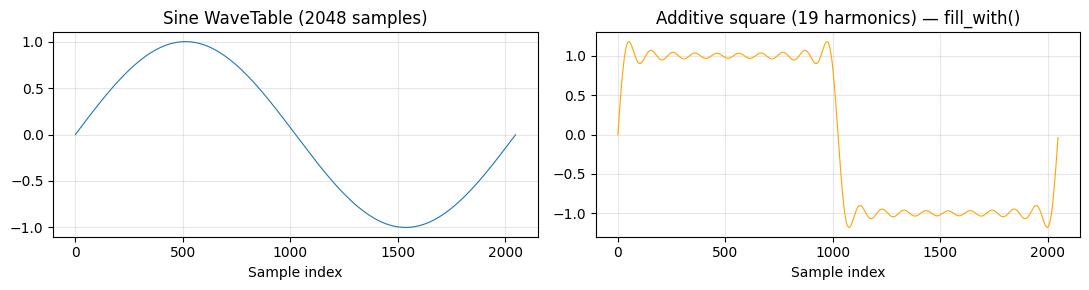

Sine peak: 1.000000
Table sample [512]: 1.000000  (expected sin(π) ≈ 0)


In [6]:
import math

table = cp.wavetable.WaveTable()
table.fill_sine()

data = table.to_numpy().copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(data, linewidth=0.8)
axes[0].set_title(f'Sine WaveTable ({len(table)} samples)')
axes[0].set_xlabel('Sample index')
axes[0].grid(True, alpha=0.3)

# Custom waveform: additive square (odd harmonics)
def additive_square(t):
    s = 0.0
    for k in range(1, 20, 2):
        s += math.sin(2 * math.pi * k * t) / k
    return s * (4 / math.pi)

table2 = cp.wavetable.WaveTable()
table2.fill_with(additive_square)
data2 = table2.to_numpy().copy()

axes[1].plot(data2, linewidth=0.8, color='orange')
axes[1].set_title('Additive square (19 harmonics) — fill_with()')
axes[1].set_xlabel('Sample index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Sine peak: {np.abs(data).max():.6f}')
print(f'Table sample [512]: {table[512]:.6f}  (expected sin(π) ≈ 0)')

## 2. Single-table oscillator — render audio

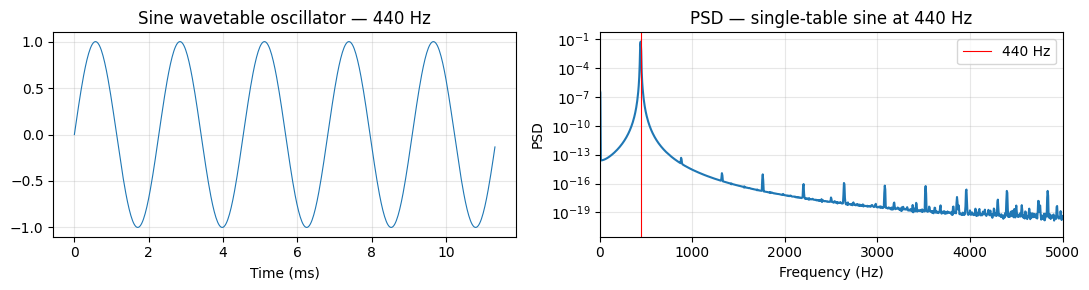

In [7]:
bank = cp.wavetable.WaveTableBank1()
bank[0].fill_sine()

osc = cp.wavetable.WavetableOscillator1(bank, float(SR), 440.0)
buf = osc.render(SR)  # 1 s

f, psd = welch(buf, fs=SR, nperseg=8192)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(np.arange(500) / SR * 1000, buf[:500], linewidth=0.8)
axes[0].set_xlabel('Time (ms)')
axes[0].set_title('Sine wavetable oscillator — 440 Hz')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(f, psd)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD')
axes[1].set_title('PSD — single-table sine at 440 Hz')
axes[1].set_xlim(0, 5000)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(440, color='red', linewidth=0.8, label='440 Hz')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Linear vs Hermite interpolation

Linear  : SNR = 73.6 dB
Hermite : SNR = 73.6 dB


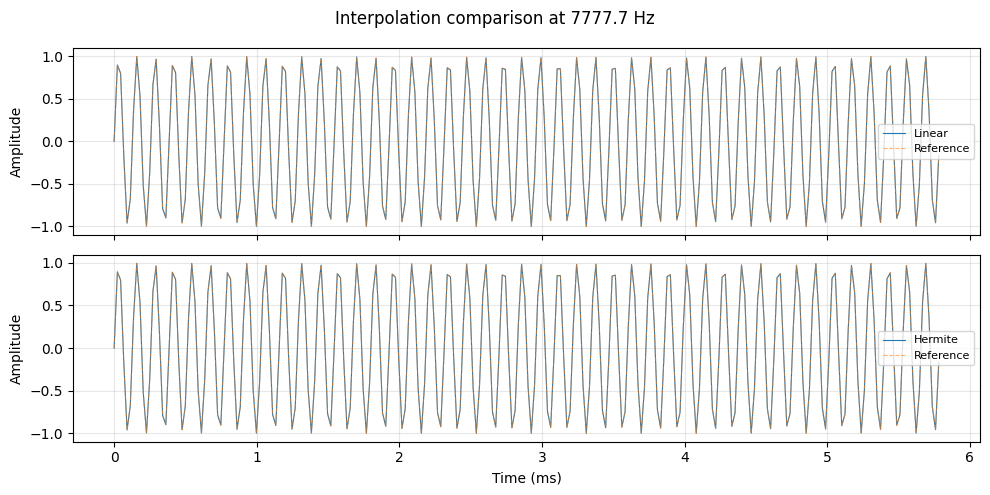

In [8]:
# Render at a non-integer multiple of the table to expose interpolation error
test_freq = 7777.7  # Hz — large phase increment per sample, worst case for interpolation
n_test    = 4096

results = {}
for mode, label in [(cp.wavetable.InterpolationMode.Linear, 'Linear'),
                    (cp.wavetable.InterpolationMode.Hermite, 'Hermite')]:
    osc_t = cp.wavetable.WavetableOscillator1(bank, float(SR), test_freq)
    osc_t.set_interpolation_mode(mode)
    results[label] = osc_t.render(n_test)

# Reference: analytic sine
t        = np.arange(n_test) / SR
ref      = np.sin(2 * np.pi * test_freq * t).astype(np.float32)

for label, buf_t in results.items():
    err   = buf_t - ref
    snr   = 10 * np.log10(np.mean(ref**2) / np.mean(err**2))
    print(f'{label:8s}: SNR = {snr:.1f} dB')

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, (label, buf_t) in zip(axes, results.items()):
    ax.plot(t[:256]*1000, buf_t[:256], linewidth=0.8, label=label)
    ax.plot(t[:256]*1000, ref[:256],   linewidth=0.8, linestyle='--', alpha=0.6, label='Reference')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle(f'Interpolation comparison at {test_freq:.1f} Hz')
plt.tight_layout()
plt.show()

## 4. 4-table morph bank

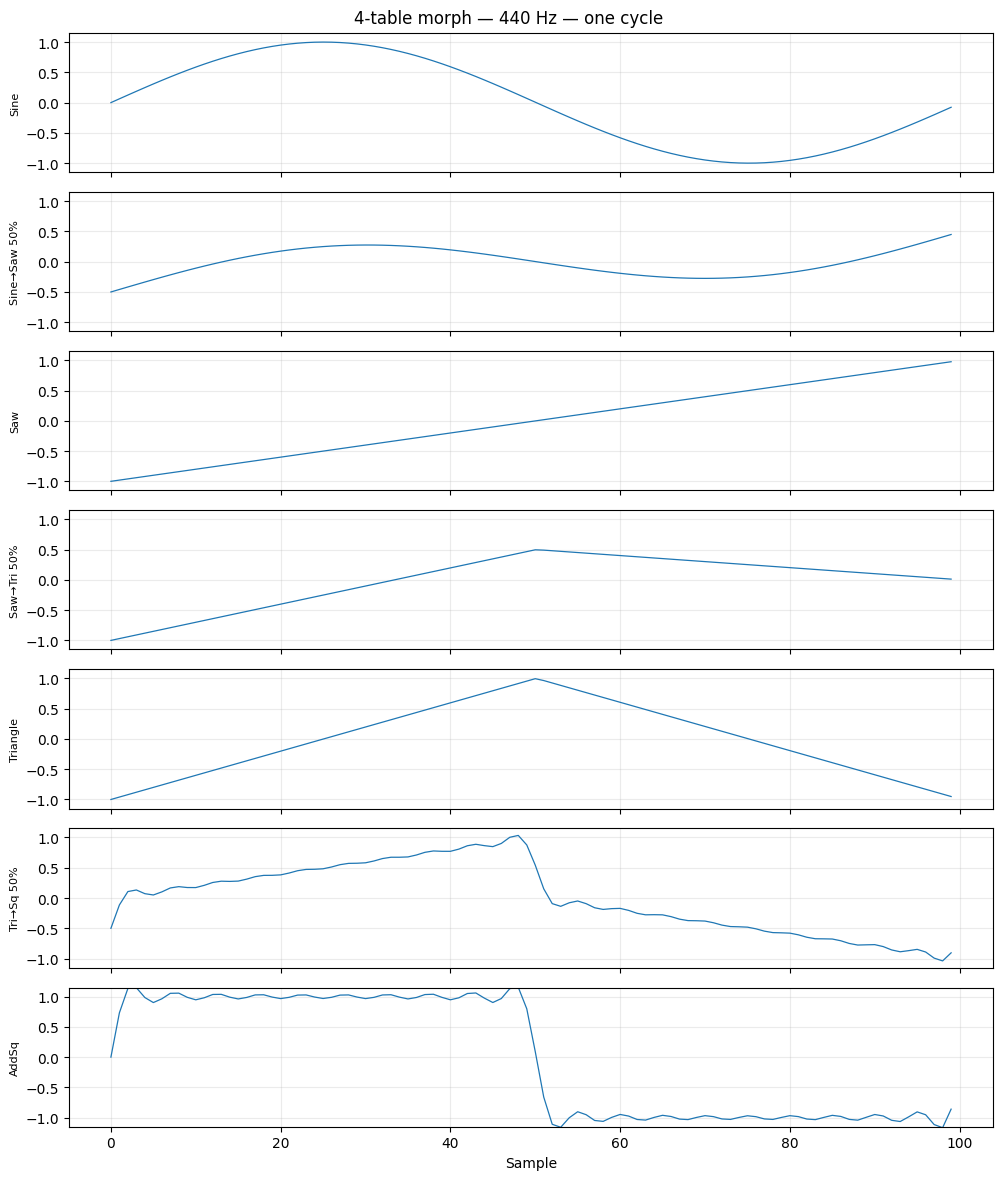

In [9]:
bank4 = cp.wavetable.WaveTableBank4()
bank4[0].fill_sine()
bank4[1].fill_saw()
bank4[2].fill_triangle()
bank4[3].fill_with(additive_square)

morph_positions = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
n_cycle  = int(SR / 440)

fig, axes = plt.subplots(len(morph_positions), 1, figsize=(10, 12), sharex=True)
labels = ['Sine', 'Sine→Saw 50%', 'Saw', 'Saw→Tri 50%', 'Triangle', 'Tri→Sq 50%', 'AddSq']

for ax, pos, lbl in zip(axes, morph_positions, labels):
    osc4 = cp.wavetable.WavetableOscillator4(bank4, float(SR), 440.0)
    osc4.set_morph_position(pos)
    buf4 = osc4.render(n_cycle)
    ax.plot(buf4, linewidth=0.9)
    ax.set_ylabel(lbl, fontsize=8)
    ax.set_ylim(-1.15, 1.15)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Sample')
fig.suptitle('4-table morph — 440 Hz — one cycle', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Phase modulation (PM / FM)

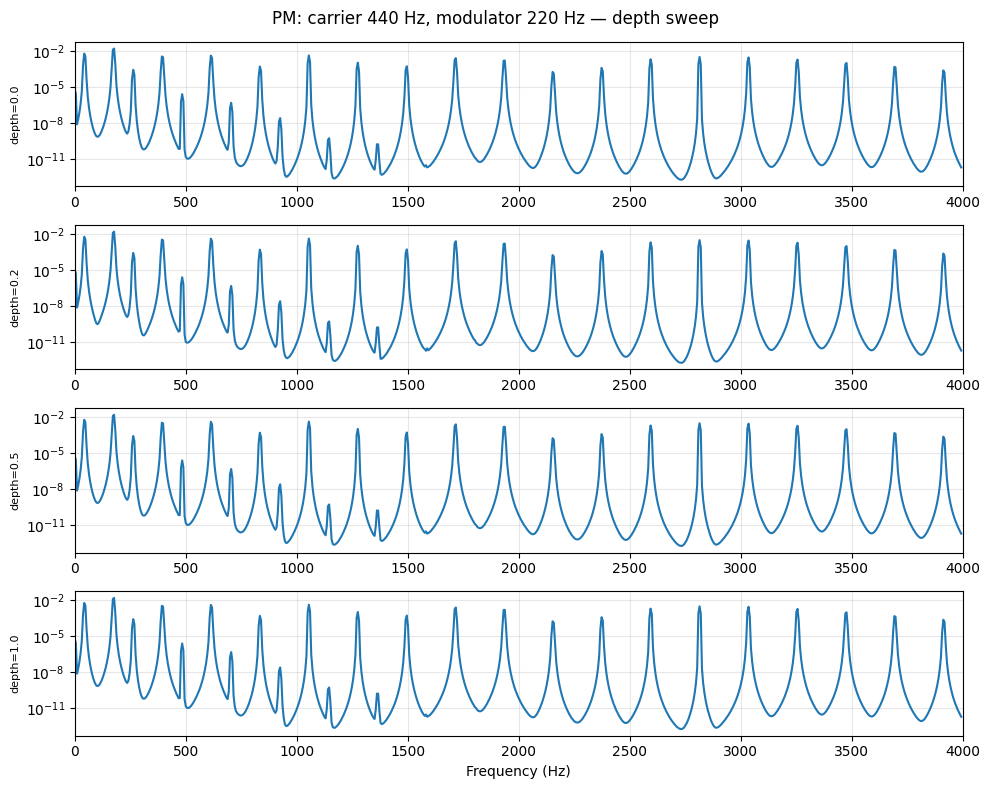

In [10]:
# Carrier at 440 Hz, modulator at 220 Hz, depth sweep
carrier_freq = 440.0
mod_freq     = 220.0
n_audio      = SR // 2

mod_bank = cp.wavetable.WaveTableBank1()
mod_bank[0].fill_sine()
car_bank = cp.wavetable.WaveTableBank1()
car_bank[0].fill_sine()

depths = [0.0, 0.2, 0.5, 1.0]
fig, axes = plt.subplots(len(depths), 1, figsize=(10, 8))

for ax, depth in zip(axes, depths):
    carrier  = cp.wavetable.WavetableOscillator1(car_bank, float(SR), carrier_freq)
    modulator = cp.wavetable.WavetableOscillator1(mod_bank, float(SR), mod_freq)
    carrier.set_phase_mod_depth(depth)

    buf_pm = np.empty(n_audio, dtype=np.float32)
    for i in range(n_audio):
        mod_out = modulator.render_sample()
        carrier.frequency.clear_modulation()
        carrier.frequency.add_modulation(mod_out * 0.3)  # slight frequency nudge
        buf_pm[i] = carrier.render_sample()

    f, psd = welch(buf_pm, fs=SR, nperseg=8192)
    ax.semilogy(f[:4000*8192//SR], psd[:4000*8192//SR])
    ax.set_ylabel(f'depth={depth}', fontsize=8)
    ax.set_xlim(0, 4000)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle('PM: carrier 440 Hz, modulator 220 Hz — depth sweep', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Hard sync — primary drives secondary

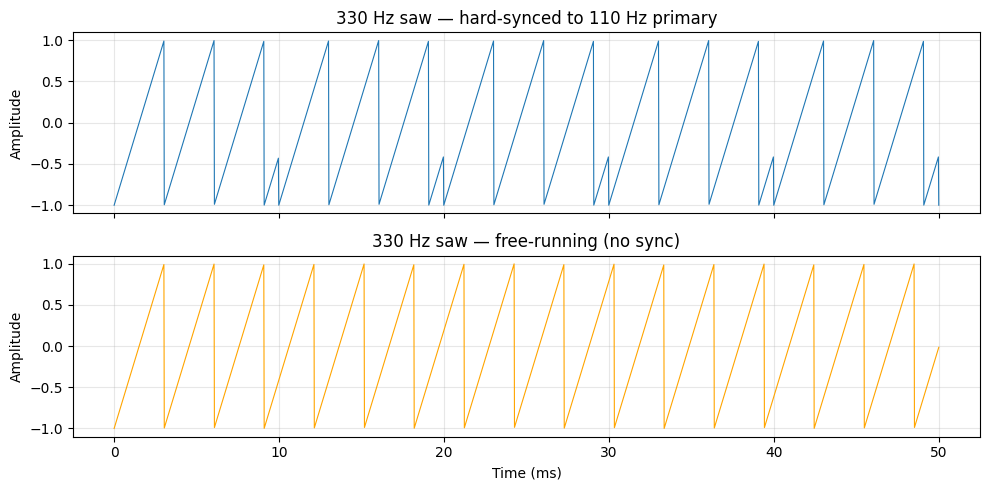

In [16]:
saw_bank = cp.wavetable.WaveTableBank1()
saw_bank[0].fill_saw()

primary   = cp.wavetable.WavetableOscillator1(saw_bank, float(SR), 100.0)
secondary = cp.wavetable.WavetableOscillator1(saw_bank, float(SR), 330.0)  # 3x ratio

n_sync = int(SR * 0.05)  # 50 ms
buf_sync = np.empty(n_sync, dtype=np.float32)
buf_free = np.empty(n_sync, dtype=np.float32)

sec_free = cp.wavetable.WavetableOscillator1(saw_bank, float(SR), 330.0)

for i in range(n_sync):
    primary.render_sample()
    if primary.phase_wrapped():
        secondary.force_sync()
    buf_sync[i] = secondary.render_sample()
    buf_free[i] = sec_free.render_sample()

t_ms = np.arange(n_sync) / SR * 1000
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t_ms, buf_sync, linewidth=0.8)
axes[0].set_title('330 Hz saw — hard-synced to 110 Hz primary')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_ms, buf_free, linewidth=0.8, color='orange')
axes[1].set_title('330 Hz saw — free-running (no sync)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (ms)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Interactive morph explorer + live audio

In [ ]:
R = 44100

# Build banks once — reused across all widget updates
bank4 = cp.wavetable.WaveTableBank4()
bank4[0].fill_sine()
bank4[1].fill_saw()
bank4[2].fill_triangle()
bank4[3].fill_with(lambda t: sum(math.sin(2 * math.pi * k * t) / k
                                 for k in range(1, 20, 2)) * (4 / math.pi))

sine_bank = cp.wavetable.WaveTableBank1()
sine_bank[0].fill_sine()

morph_labels = ['Sine', 'Sine→Saw', 'Saw', 'Saw→Tri', 'Triangle', 'Tri→Sq', 'AddSq']

# ── Widgets ──────────────────────────────────────────────────────────────────
w_freq      = widgets.FloatLogSlider(value=880, base=10,
                                     min=np.log10(20), max=np.log10(8000),
                                     description='Carrier (Hz)',
                                     continuous_update=False)
w_morph     = widgets.FloatSlider(value=0.0, min=0.0, max=3.0, step=0.05,
                                   description='Morph pos',
                                   continuous_update=False)
w_dur       = widgets.FloatSlider(value=0.25, min=0.05, max=1.0, step=0.05,
                                   description='Duration (s)',
                                   continuous_update=False)
w_interp    = widgets.ToggleButtons(options=['Linear', 'Hermite'],
                                     description='Interp')
w_sync_en   = widgets.Checkbox(value=False, description='Hard sync')
w_sync_freq = widgets.FloatLogSlider(value=110, base=10,
                                     min=np.log10(20), max=np.log10(4000),
                                     description='Primary (Hz)',
                                     continuous_update=False)
out_wt      = widgets.Output()

interp_map = {
    'Linear':  cp.wavetable.InterpolationMode.Linear,
    'Hermite': cp.wavetable.InterpolationMode.Hermite,
}

# ── Callback ─────────────────────────────────────────────────────────────────
def update_wt(_):
    n     = int(SR * w_dur.value)
    freq  = float(w_freq.value)

    osc = cp.wavetable.WavetableOscillator4(bank4, float(SR), freq)
    osc.set_morph_position(w_morph.value)
    osc.set_interpolation_mode(interp_map[w_interp.value])

    if w_sync_en.value:
        primary_freq = float(w_sync_freq.value)
        primary      = cp.wavetable.WavetableOscillator1(
                           sine_bank, float(SR), primary_freq)
        buf, sync_points = cp.wavetable.render_hard_sync(primary, osc, n)
        n_show = min(int(SR / primary_freq * 4), n)
        title  = (f'Carrier {freq:.0f} Hz — primary {primary_freq:.0f} Hz'
                  f' — morph={w_morph.value:.2f}')
    else:
        buf          = osc.render(n)
        sync_points  = []
        n_show       = min(int(SR / max(freq, 1) * 4), n)
        morph_label  = morph_labels[min(int(round(w_morph.value * 2)),
                                        len(morph_labels) - 1)]
        title        = f'{freq:.1f} Hz — {morph_label} (morph={w_morph.value:.2f})'

    f, psd = welch(buf, fs=SR, nperseg=min(8192, n))
    t_ms   = np.arange(n_show) / SR * 1000

    with out_wt:
        out_wt.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(11, 3))

        axes[0].plot(t_ms, buf[:n_show], linewidth=0.8)
        for sp in sync_points:
            if sp < n_show:
                axes[0].axvline(sp / SR * 1000, color='red',
                                linewidth=0.7, alpha=0.6, linestyle='--')
        axes[0].set_xlabel('Time (ms)')
        axes[0].set_title(title)
        axes[0].grid(True, alpha=0.3)

        axes[1].semilogy(f, psd)
        axes[1].set_xlabel('Frequency (Hz)')
        axes[1].set_ylabel('PSD')
        axes[1].set_xlim(0, min(freq * 20, SR / 2))
        axes[1].set_title('Spectrum')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        fade       = np.ones(n)
        fl         = min(2000, n // 4)
        fade[:fl]  = np.linspace(0, 1, fl)
        fade[-fl:] = np.linspace(1, 0, fl)
        display(Audio(buf * fade * 0.5, rate=SR, normalize=False))

# ── Wire up and display ───────────────────────────────────────────────────────
for w in [w_freq, w_morph, w_dur, w_interp, w_sync_en, w_sync_freq]:
    w.observe(update_wt, names='value')

update_wt(None)
display(widgets.VBox([
    widgets.HBox([w_freq,    w_morph]),
    widgets.HBox([w_dur,     w_interp]),
    widgets.HBox([w_sync_en, w_sync_freq]),
    out_wt,
]))